 Cell 1 — Imports   

In [44]:
!pip install imbalanced-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import os

Cell 2 — Load raw data 

In [45]:
df = pd.read_csv("../data/raw/framingham.csv")
df_before = pd.read_csv("../data/raw/framingham.csv")  # add this line
print(df.shape)

(4240, 16)


Cell 3 — Median imputation

In [46]:
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


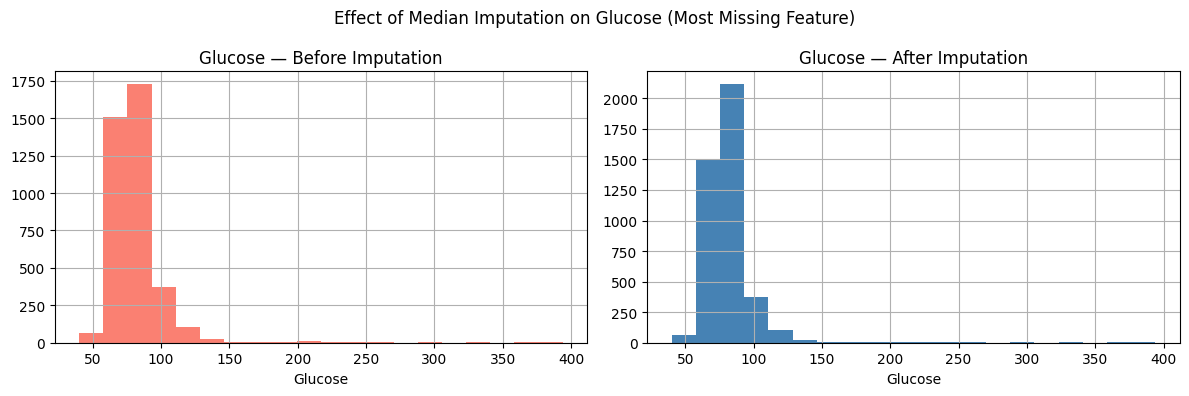

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_before['glucose'].hist(ax=axes[0], bins=20, color='salmon')
axes[0].set_title('Glucose — Before Imputation')
axes[0].set_xlabel('Glucose')

df['glucose'].hist(ax=axes[1], bins=20, color='steelblue')
axes[1].set_title('Glucose — After Imputation')
axes[1].set_xlabel('Glucose')

plt.suptitle('Effect of Median Imputation on Glucose (Most Missing Feature)')
plt.tight_layout()
plt.show()

Cell 4 — Train / Val / Test split (70/15/15)

In [48]:
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2968, 15), Val: (636, 15), Test: (636, 15)


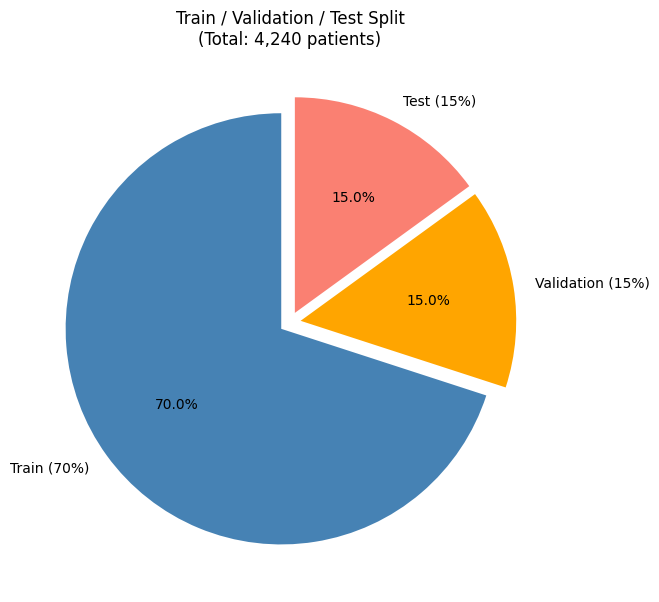

In [49]:
labels = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['steelblue', 'orange', 'salmon']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=explode)
plt.title('Train / Validation / Test Split\n(Total: 4,240 patients)')
plt.show()

Cell 5 — Feature scaling

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)         # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

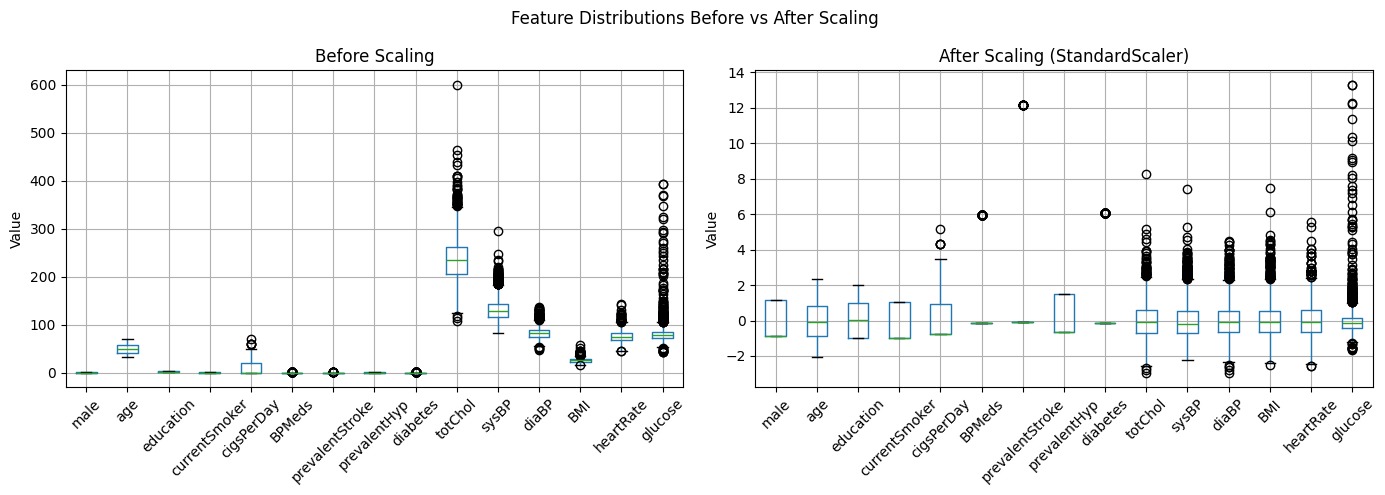

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.DataFrame(X_train, columns=X.columns).boxplot(ax=axes[0], rot=45)
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

pd.DataFrame(X_train_scaled, columns=X.columns).boxplot(ax=axes[1], rot=45)
axes[1].set_title('After Scaling (StandardScaler)')
axes[1].set_ylabel('Value')

plt.suptitle('Feature Distributions Before vs After Scaling')
plt.tight_layout()
plt.show()

Cell 6 - Apply Smote


In [52]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Original training class distribution:")
print(pd.Series(y_train).value_counts())
print("\nResampled training class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Original training class distribution:
TenYearCHD
0    2517
1     451
Name: count, dtype: int64

Resampled training class distribution:
TenYearCHD
0    2517
1    2517
Name: count, dtype: int64


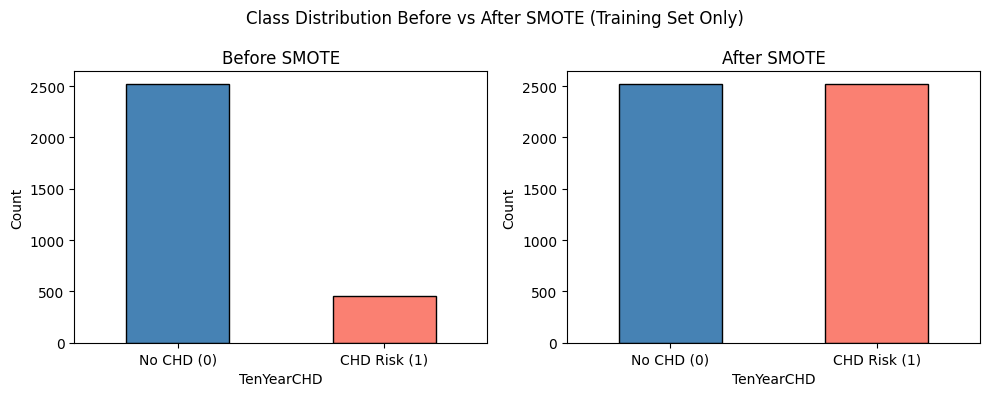

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], 
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('TenYearCHD')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No CHD (0)', 'CHD Risk (1)'], rotation=0)

pd.Series(y_train_resampled).value_counts().plot(
    kind='bar', ax=axes[1], 
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('TenYearCHD')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No CHD (0)', 'CHD Risk (1)'], rotation=0)

plt.suptitle('Class Distribution Before vs After SMOTE (Training Set Only)')
plt.tight_layout()
plt.show()

Cell 6 — Save processed data

In [54]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Save resampled train (with SMOTE)
pd.DataFrame(X_train_resampled, columns=X.columns)\
  .assign(TenYearCHD=y_train_resampled)\
  .to_csv("../data/processed/train.csv", index=False)

# Save val and test (no SMOTE — real data only)
pd.DataFrame(X_val_scaled, columns=X.columns)\
  .assign(TenYearCHD=y_val.values)\
  .to_csv("../data/processed/val.csv", index=False)

pd.DataFrame(X_test_scaled, columns=X.columns)\
  .assign(TenYearCHD=y_test.values)\
  .to_csv("../data/processed/test.csv", index=False)

# Save scaler for teammates
joblib.dump(scaler, "../models/scaler.pkl")

print("Saved train (SMOTE), val, test to data/processed/")
print("Saved scaler to models/scaler.pkl")

Saved train (SMOTE), val, test to data/processed/
Saved scaler to models/scaler.pkl
